<center>
<img src="https://laelgelcpublic.s3.sa-east-1.amazonaws.com/lael_50_years_narrow_white.png.no_years.400px_96dpi.png" width="300" alt="LAEL 50 years logo">
<h3>APPLIED LINGUISTICS GRADUATE PROGRAMME (LAEL)</h3>
</center>
<hr>

# Normalize filenames in `corpus/00_source_ef_sudeste_pilot`

In [4]:
import os
import re

base_dir = "corpus/00_source_ef_sudeste_pilot"

# Set to True to actually rename files, False to only preview changes
apply_changes = True

for filename in os.listdir(base_dir):
    old_path = os.path.join(base_dir, filename)
    if not os.path.isfile(old_path):
        continue

    name, ext = os.path.splitext(filename)

    # 1) Lowercase
    new_name = name.lower()

    # 2) Replace spaces with underscores
    new_name = new_name.replace(" ", "_")

    # 3) Collapse multiple underscores into a single one
    new_name = re.sub(r"_+", "_", new_name)

    # Reattach extension (extension is kept as-is; make it lowercase if desired)
    new_filename = f"{new_name}{ext}"

    # Skip if name would not change
    if new_filename == filename:
        continue

    new_path = os.path.join(base_dir, new_filename)

    print(f"{filename}  ->  {new_filename}")

    if apply_changes:
        os.rename(old_path, new_path)

# Join non-empty lines into paragraphs in `corpus/00_source_ef_sudeste_pilot`

In [5]:
import os
from pathlib import Path

base_dir = Path("corpus/00_source_ef_sudeste_pilot")

# Set to True to actually overwrite the original files
#apply_changes = False
apply_changes = True

def join_non_empty_lines_into_paragraphs(text: str) -> str:
    paragraphs = []
    current_paragraph_lines = []

    for raw_line in text.splitlines():
        line = raw_line.strip()
        if line == "":
            # Empty line: end of current paragraph (if any)
            if current_paragraph_lines:
                paragraphs.append(" ".join(current_paragraph_lines))
                current_paragraph_lines = []
        else:
            current_paragraph_lines.append(line)

    # Add last paragraph if the file doesn't end with a blank line
    if current_paragraph_lines:
        paragraphs.append(" ".join(current_paragraph_lines))

    # Join paragraphs with a single blank line between them
    return "\n\n".join(paragraphs) + "\n"

for path in base_dir.iterdir():
    if not path.is_file() or path.suffix.lower() != ".txt":
        continue

    with path.open("r", encoding="utf-8") as f:
        original_text = f.read()

    new_text = join_non_empty_lines_into_paragraphs(original_text)

    # Skip if nothing would change
    if new_text == original_text:
        continue

    print(f"Updating: {path.name}")

    # Optional: quick preview of first and last paragraphs
    preview_paragraphs = new_text.strip().split("\n\n")
    if preview_paragraphs:
        print("  First paragraph:", preview_paragraphs[0][:120], "...")
        if len(preview_paragraphs) > 1:
            print("  Last paragraph:", preview_paragraphs[-1][:120], "...")
    print()

    if apply_changes:
        with path.open("w", encoding="utf-8") as f:
            f.write(new_text)

# Create DataFrame of source EF Sudeste pilot filenames

In [6]:
import pandas as pd

# Ensure base_dir points to the desired folder; reuse existing variable if already defined
# from pathlib import Path
# base_dir = Path("corpus/00_source_ef_sudeste_pilot")

filenames = sorted([p.name for p in base_dir.iterdir() if p.is_file()])

source_ef_sudeste_pilot_df = pd.DataFrame({"filename": filenames})
source_ef_sudeste_pilot_df

,filename
0,es_ef_anos_finais_ciencias_da_natureza.txt
1,es_ef_anos_finais_linguagens_ingles_1.txt
2,es_ef_anos_finais_linguagens_ingles_2.txt
3,es_ef_anos_iniciais_arte_2.txt
4,es_ef_anos_iniciais_arte_3.txt
...,...
235,sp_inf_e_ef_intro_5.txt
236,sp_inf_e_ef_intro_6.txt
237,sp_inf_e_ef_intro_7.txt
238,sp_inf_e_ef_intro_8.txt


In [7]:
source_ef_sudeste_pilot_df["state"] = source_ef_sudeste_pilot_df["filename"].str.split("_", n=1).str[0]
source_ef_sudeste_pilot_df

,filename,state
0,es_ef_anos_finais_ciencias_da_natureza.txt,es
1,es_ef_anos_finais_linguagens_ingles_1.txt,es
2,es_ef_anos_finais_linguagens_ingles_2.txt,es
3,es_ef_anos_iniciais_arte_2.txt,es
4,es_ef_anos_iniciais_arte_3.txt,es
...,...,...
235,sp_inf_e_ef_intro_5.txt,sp
236,sp_inf_e_ef_intro_6.txt,sp
237,sp_inf_e_ef_intro_7.txt,sp
238,sp_inf_e_ef_intro_8.txt,sp


In [8]:
state_counts = source_ef_sudeste_pilot_df["state"].value_counts()
state_percent = source_ef_sudeste_pilot_df["state"].value_counts(normalize=True) * 100

state_summary = (
    pd.DataFrame({"count": state_counts, "percent": state_percent})
    .reset_index()
    .rename(columns={"index": "state"})
)

state_summary

,state,count,percent
0,mg,113,47.083333
1,sp,48,20.000000
2,rj,42,17.500000
3,es,37,15.416667


# Create paragraph-level filenames and word counts

In [9]:
import os
from pathlib import Path
import pandas as pd

base_dir = Path("corpus/00_source_ef_sudeste_pilot")

paragraph_rows = []

for _, row in source_ef_sudeste_pilot_df.iterrows():
    filename = row["filename"]
    state = row["state"]
    path = base_dir / filename

    with path.open("r", encoding="utf-8") as f:
        text = f.read().strip()

    # Split paragraphs by blank lines (files were normalized so each paragraph is a block of text)
    paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]

    name, ext = os.path.splitext(filename)

    for i, paragraph in enumerate(paragraphs, start=1):
        filename_paragraph = f"{name}_p{i}{ext}"
        word_count = len(paragraph.split())

        paragraph_rows.append(
            {
                "filename": filename,
                "state": state,
                "paragraph_index": i,
                "filename_paragraph": filename_paragraph,
                "word_count": word_count,
            }
        )

source_ef_sudeste_pilot_paragraph_df = pd.DataFrame(paragraph_rows)
source_ef_sudeste_pilot_paragraph_df.head()

,filename,state,paragraph_index,filename_paragraph,word_count
0,es_ef_anos_finais_ciencias_da_natureza.txt,es,1,es_ef_anos_finais_ciencias_da_natureza_p1.txt,79
1,es_ef_anos_finais_ciencias_da_natureza.txt,es,2,es_ef_anos_finais_ciencias_da_natureza_p2.txt,66
2,es_ef_anos_finais_ciencias_da_natureza.txt,es,3,es_ef_anos_finais_ciencias_da_natureza_p3.txt,97
3,es_ef_anos_finais_linguagens_ingles_1.txt,es,1,es_ef_anos_finais_linguagens_ingles_1_p1.txt,56
4,es_ef_anos_finais_linguagens_ingles_1.txt,es,2,es_ef_anos_finais_linguagens_ingles_1_p2.txt,65


# Describe and visualize paragraph word counts

count    2394.000000
mean       77.411028
std        55.147925
min         1.000000
25%        42.000000
50%        64.000000
75%        97.750000
max       823.000000
Name: word_count, dtype: float64

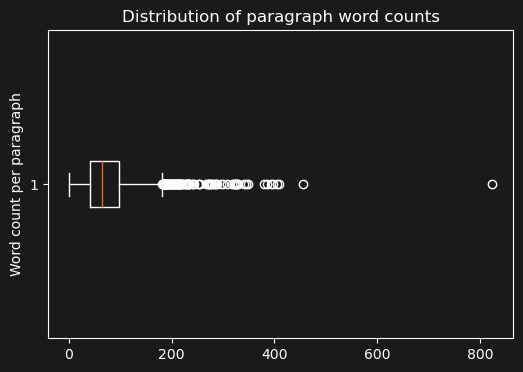

In [10]:
import matplotlib.pyplot as plt

# Descriptive statistics
word_count_stats = source_ef_sudeste_pilot_paragraph_df["word_count"].describe()
display(word_count_stats)

# Boxplot of word counts
plt.figure(figsize=(6, 4))
plt.boxplot(source_ef_sudeste_pilot_paragraph_df["word_count"], vert=False)
plt.ylabel("Word count per paragraph")
plt.title("Distribution of paragraph word counts")
plt.show()

# Outliers

In [11]:
import numpy as np

wc = source_ef_sudeste_pilot_paragraph_df["word_count"]

q1 = wc.quantile(0.25)
q3 = wc.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outlier_mask = (wc < lower_bound) | (wc > upper_bound)
n_outliers = outlier_mask.sum()

total_paragraphs = len(source_ef_sudeste_pilot_paragraph_df)

print(f"Total paragraphs: {total_paragraphs}")
print(f"IQR-based lower bound: {lower_bound:.2f}")
print(f"IQR-based upper bound: {upper_bound:.2f}")
print(f"Number of outlier paragraphs: {n_outliers}")
print(f"Percentage of outliers: {n_outliers / total_paragraphs * 100:.2f}%")

Total paragraphs: 2394
IQR-based lower bound: -41.62
IQR-based upper bound: 181.38
Number of outlier paragraphs: 106
Percentage of outliers: 4.43%


# Label paragraph word-count outliers

In [12]:
# Add a boolean outlier flag based on the IQR bounds
source_ef_sudeste_pilot_paragraph_df["outlier"] = (
        (source_ef_sudeste_pilot_paragraph_df["word_count"] < lower_bound) |
        (source_ef_sudeste_pilot_paragraph_df["word_count"] > upper_bound)
)

source_ef_sudeste_pilot_paragraph_df["outlier"].value_counts()

outlier
False    2288
True      106
Name: count, dtype: int64

# Export paragraph-level data to NDJSON

In [14]:
output_path = "corpus/source_ef_sudeste_pilot_paragraph.ndjson"

source_ef_sudeste_pilot_paragraph_df.to_json(
    output_path,
    orient="records",
    lines=True,
    force_ascii=False
)

output_path

'corpus/source_ef_sudeste_pilot_paragraph.ndjson'

# Export non-outlier paragraphs to per-state corpus files

In [15]:
from pathlib import Path

# Base directories
source_base_dir = Path("corpus/00_source_ef_sudeste_pilot")
output_root = Path("corpus/02_extracted")

# Create root output directory and one subdirectory per state
output_root.mkdir(parents=True, exist_ok=True)

states = source_ef_sudeste_pilot_paragraph_df["state"].unique()
for state in states:
    state_dir = output_root / state
    state_dir.mkdir(exist_ok=True)

# Optional: respect existing apply_changes flag (default to True if not defined)
try:
    apply_changes
except NameError:
    apply_changes = True

# Cache paragraphs per source file so we don't re-read files for every row
paragraph_cache = {}

def get_paragraphs_for_filename(filename: str):
    """Load and split the source file into paragraphs, caching the result."""
    if filename not in paragraph_cache:
        path = source_base_dir / filename
        text = path.read_text(encoding="utf-8").strip()
        paragraphs = [p.strip() for p in text.split("\n\n") if p.strip()]
        paragraph_cache[filename] = paragraphs
    return paragraph_cache[filename]

# Write one file per non-outlier paragraph into the corresponding state subdirectory
non_outliers = source_ef_sudeste_pilot_paragraph_df[
    ~source_ef_sudeste_pilot_paragraph_df["outlier"]
]

for _, row in non_outliers.iterrows():
    filename = row["filename"]
    state = row["state"]
    paragraph_index = int(row["paragraph_index"])
    filename_paragraph = row["filename_paragraph"]

    paragraphs = get_paragraphs_for_filename(filename)

    # Paragraph indices in the DataFrame are 1-based; Python lists are 0-based
    if 1 <= paragraph_index <= len(paragraphs):
        paragraph_text = paragraphs[paragraph_index - 1]
    else:
        # Skip if something is inconsistent
        print(f"Warning: paragraph_index {paragraph_index} out of range for {filename}")
        continue

    state_dir = output_root / state
    out_path = state_dir / filename_paragraph

    print(f"Writing: {out_path}")

    if apply_changes:
        out_path.write_text(paragraph_text + "\n", encoding="utf-8")

Writing: corpus/02_extracted/es/es_ef_anos_finais_ciencias_da_natureza_p1.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_ciencias_da_natureza_p2.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_ciencias_da_natureza_p3.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_1_p1.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_1_p2.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_1_p4.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_1_p6.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_1_p7.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_1_p8.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_2_p1.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_2_p2.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_2_p3.txt
Writing: corpus/02_extracted/es/es_ef_anos_finais_linguagens_ingles_2_p4.

In [17]:
import pandas as pd

total_non_outliers = non_outlier_counts_by_state["non_outlier_paragraphs"].sum()

non_outlier_counts_with_total = pd.concat(
    [
        non_outlier_counts_by_state,
        pd.DataFrame(
            {"state": ["Total"], "non_outlier_paragraphs": [total_non_outliers]}
        ),
    ],
    ignore_index=True,
)

non_outlier_counts_with_total

,state,non_outlier_paragraphs
0,es,449
1,mg,843
2,rj,433
3,sp,563
4,Total,2288


# Load paragraph-level NDJSON into DataFrame

In [1]:
import pandas as pd

source_ef_sudeste_pilot_paragraph_df = pd.read_json(
    "corpus/source_ef_sudeste_pilot_paragraph.ndjson",
    lines=True
)

source_ef_sudeste_pilot_paragraph_df.head()

,filename,state,paragraph_index,filename_paragraph,word_count,outlier
0,es_ef_anos_finais_ciencias_da_natureza.txt,es,1,es_ef_anos_finais_ciencias_da_natureza_p1.txt,79,False
1,es_ef_anos_finais_ciencias_da_natureza.txt,es,2,es_ef_anos_finais_ciencias_da_natureza_p2.txt,66,False
2,es_ef_anos_finais_ciencias_da_natureza.txt,es,3,es_ef_anos_finais_ciencias_da_natureza_p3.txt,97,False
3,es_ef_anos_finais_linguagens_ingles_1.txt,es,1,es_ef_anos_finais_linguagens_ingles_1_p1.txt,56,False
4,es_ef_anos_finais_linguagens_ingles_1.txt,es,2,es_ef_anos_finais_linguagens_ingles_1_p2.txt,65,False


# Determine the number of paragraphs that are shorter than 10 words

In [3]:
num_short_paragraphs = (source_ef_sudeste_pilot_paragraph_df["word_count"] < 10).sum()

print(f"Number of paragraphs with fewer than 10 words: {num_short_paragraphs}")

Number of paragraphs with fewer than 10 words: 17


In [6]:
# Flag paragraphs shorter than 10 words
source_ef_sudeste_pilot_paragraph_df["shorter_than_10_words"] = (
        source_ef_sudeste_pilot_paragraph_df["word_count"] < 10
)

# Show a slice containing only short paragraphs (e.g., first 10)
short_paragraphs_slice = source_ef_sudeste_pilot_paragraph_df[
    source_ef_sudeste_pilot_paragraph_df["shorter_than_10_words"]
]

short_paragraphs_slice

,filename,state,paragraph_index,filename_paragraph,word_count,outlier,shorter_than_10_words
38,es_ef_anos_iniciais_arte_3.txt,es,1,es_ef_anos_iniciais_arte_3_p1.txt,8,False,True
64,es_ef_anos_iniciais_arte_5.txt,es,6,es_ef_anos_iniciais_arte_5_p6.txt,9,False,True
121,es_ef_anos_iniciais_ciencias_da_natureza_4.txt,es,8,es_ef_anos_iniciais_ciencias_da_natureza_4_p8.txt,9,False,True
128,es_ef_anos_iniciais_ciencias_humanas_geo_1.txt,es,1,es_ef_anos_iniciais_ciencias_humanas_geo_1_p1.txt,1,False,True
140,es_ef_anos_iniciais_ciencias_humanas_geo_1.txt,es,13,es_ef_anos_iniciais_ciencias_humanas_geo_1_p13...,9,False,True
158,es_ef_anos_iniciais_ciencias_humanas_geo_2.txt,es,12,es_ef_anos_iniciais_ciencias_humanas_geo_2_p12...,9,False,True
173,es_ef_anos_iniciais_ciencias_humanas_historia_...,es,8,es_ef_anos_iniciais_ciencias_humanas_historia_...,8,False,True
192,es_ef_anos_iniciais_ciencias_humanas_historia_...,es,12,es_ef_anos_iniciais_ciencias_humanas_historia_...,4,False,True
196,es_ef_anos_iniciais_ciencias_humanas_historia_...,es,16,es_ef_anos_iniciais_ciencias_humanas_historia_...,9,False,True
209,es_ef_anos_iniciais_ciencias_humanas_intro.txt,es,1,es_ef_anos_iniciais_ciencias_humanas_intro_p1.txt,5,False,True


# Overwrite paragraph-level NDJSON with updated DataFrame

In [8]:
# Overwrite the NDJSON file with the updated DataFrame
source_ef_sudeste_pilot_paragraph_df.to_json(
    "corpus/source_ef_sudeste_pilot_paragraph.ndjson",
    orient="records",
    lines=True,
    force_ascii=False,
)

"corpus/source_ef_sudeste_pilot_paragraph.ndjson"

'corpus/source_ef_sudeste_pilot_paragraph.ndjson'

# Delete paragraph files shorter than 10 words from `corpus/02_extracted`

In [9]:
from pathlib import Path

base_extracted_dir = Path("corpus/02_extracted")

# Filter DataFrame for paragraphs shorter than 10 words
short_rows = source_ef_sudeste_pilot_paragraph_df[
    source_ef_sudeste_pilot_paragraph_df["shorter_than_10_words"]
]

deleted_count = 0

for _, row in short_rows.iterrows():
    state = row["state"]
    filename_paragraph = row["filename_paragraph"]

    # Files are stored under corpus/02_extracted/<state>/<filename_paragraph>
    file_path = base_extracted_dir / state / filename_paragraph

    if file_path.is_file():
        # Log relative path and delete
        rel_path = file_path.as_posix()
        print(f"Deleting: {rel_path}")
        file_path.unlink()
        deleted_count += 1
    else:
        # Log missing files for transparency
        rel_path = file_path.as_posix()
        print(f"Not found (skipped): {rel_path}")

print(f"\nTotal files deleted (shorter than 10 words): {deleted_count}")

Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_arte_3_p1.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_arte_5_p6.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_ciencias_da_natureza_4_p8.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_ciencias_humanas_geo_1_p1.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_ciencias_humanas_geo_1_p13.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_ciencias_humanas_geo_2_p12.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_ciencias_humanas_historia_1_p8.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_ciencias_humanas_historia_2_p12.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_ciencias_humanas_historia_2_p16.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_ciencias_humanas_intro_p1.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_ensino_religioso_2_p13.txt
Deleting: corpus/02_extracted/es/es_ef_anos_iniciais_linguagens_ed_fis_2_p4.txt
Deleting: corpus/02_ext